In [ ]:
import sys
import time
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Add src to path for imports
sys.path.insert(0, str(Path.cwd()))
sys.path.append(os.path.abspath(".."))

from model_training import load_splits, evaluate_model, compare_models, plot_confusion_matrix

In [ ]:
# Load and split the dataset
print("="*70)
print("STEP 1: Loading and splitting the CICIDS2017 cleaned dataset")
print("="*70)

X_train, X_test, y_train, y_test = load_splits()

print(f"\nFeature columns: {X_train.shape[1]}")
print(f"Classes: {sorted(y_train.unique())}")

STEP 1: Loading and splitting the CICIDS2017 cleaned dataset
Loading data from: /Users/anhoang/Documents/Projects/DAP391m/Project/cicids2017_cleaned.csv
 → Loaded 2,520,762 rows × 53 columns

Class distribution (%):
                             Full  Train   Test
Attack Type                                    
BENIGN                      83.11  83.11  83.11
DoS                          7.69   7.69   7.69
DDoS                         5.08   5.08   5.08
PortScan                     3.60   3.60   3.60
Brute Force                  0.36   0.36   0.36
Bot                          0.08   0.08   0.08
Web Attack � Brute Force     0.06   0.06   0.06
Web Attack � XSS             0.03   0.03   0.03
Web Attack � Sql Injection   0.00   0.00   0.00
Heartbleed                   0.00   0.00   0.00

Train size: 2,016,609  |  Test size: 504,153

Splits saved to /Users/anhoang/Documents/Projects/DAP391m/Project/splits/

Feature columns: 52
Classes: ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Heartble

In [ ]:
print("\n" + "="*70)
print("STEP 2: Training Random Forest Classifier")
print("="*70)

t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nTraining model on training set...")
rf_model.fit(X_train, y_train)

train_time = time.time() - t0
print(f"\n✓ Training completed in {train_time:.2f} seconds")


STEP 2: Training Random Forest Classifier

Training model on training set...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   28.4s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  2.6min



✓ Training completed in 260.52 seconds


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  4.3min finished


In [ ]:
print("\n" + "="*70)
print("STEP 3: Model Evaluation on Test Set")
print("="*70)

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

# Evaluate model
rf_results = evaluate_model(y_test, y_pred, "Random Forest (n_estimators=300)", y_pred_proba=y_proba)

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.



STEP 3: Model Evaluation on Test Set


[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.2s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.8s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    1.3s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.8s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    1.3s finished



  Random Forest (n_estimators=300) — Evaluation Results
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.89      0.76      0.82       390
               Brute Force       1.00      1.00      1.00      1830
                      DDoS       1.00      1.00      1.00     25603
                       DoS       1.00      1.00      1.00     38749
                Heartbleed       1.00      1.00      1.00         2
                  PortScan       0.99      0.99      0.99     18139
  Web Attack � Brute Force       0.74      0.81      0.77       294
Web Attack � Sql Injection       0.50      0.25      0.33         4
          Web Attack � XSS       0.43      0.31      0.36       130

                  accuracy                           1.00    504153
                 macro avg       0.85      0.81      0.83    504153
              weighted avg       1.00      1.00      1.00


STEP 4: Plotting Confusion Matrix


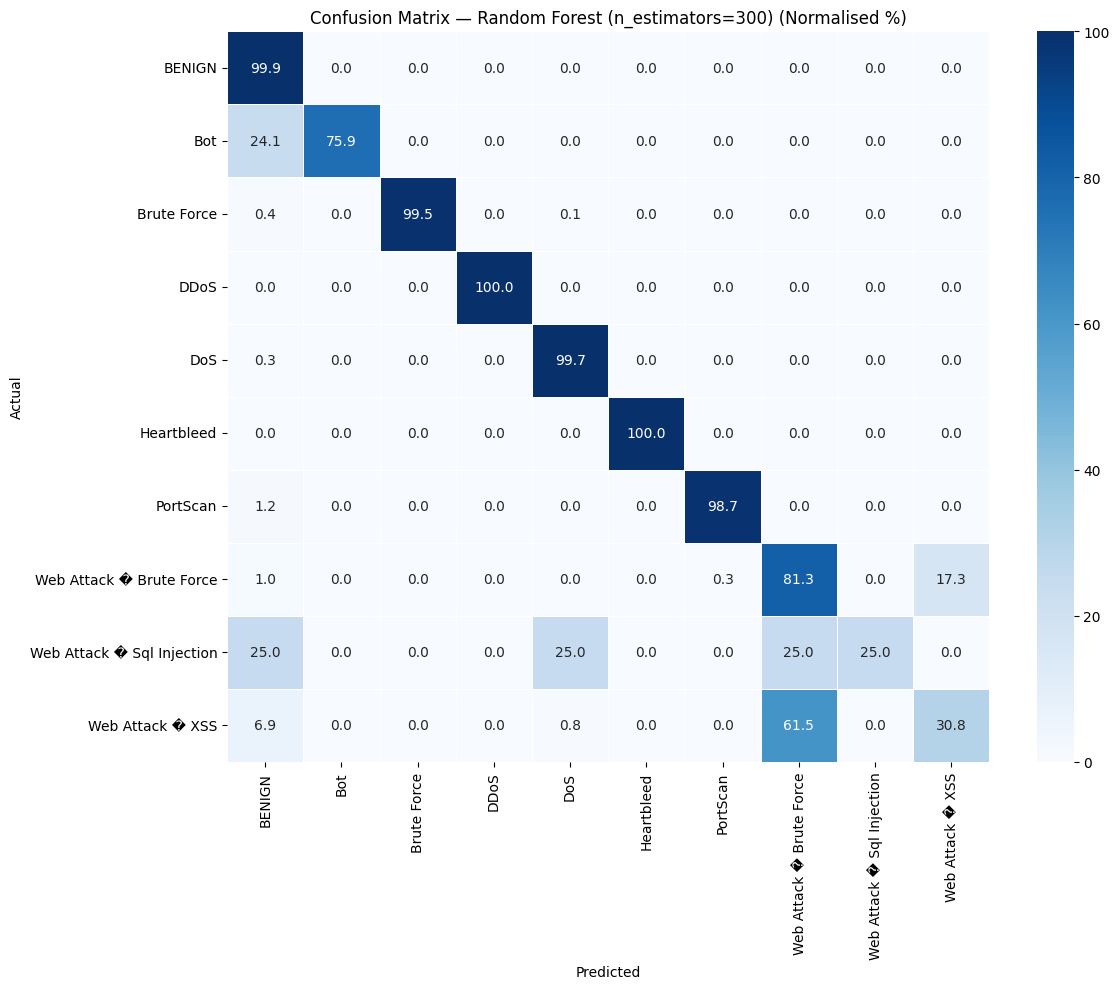

In [5]:
print("\n" + "="*70)
print("STEP 4: Plotting Confusion Matrix")
print("="*70)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
    labels=rf_model.classes_.tolist(),
    model_name="Random Forest (n_estimators=300)",
    normalize=True,
    figsize=(12, 10),
    save_path=None
)


STEP 5: Feature Importance Analysis

Top 20 Most Important Features:
                    Feature  Importance
      Bwd Packet Length Std    0.076445
     Packet Length Variance    0.068593
          Packet Length Std    0.066195
      Bwd Packet Length Max    0.050954
     Bwd Packet Length Mean    0.047449
        Average Packet Size    0.046463
Total Length of Fwd Packets    0.046018
          Subflow Fwd Bytes    0.042772
          Max Packet Length    0.036106
      Fwd Packet Length Max    0.032600
         Packet Length Mean    0.031410
                Fwd IAT Std    0.025904
           Destination Port    0.025126
          Total Fwd Packets    0.024443
           act_data_pkt_fwd    0.022851
    Init_Win_bytes_backward    0.021661
          Bwd Header Length    0.020751
     Fwd Packet Length Mean    0.018695
               Flow IAT Max    0.018129
      Fwd Packet Length Std    0.017699


/var/folders/7z/vsmzd7593_lgbdjr7bpskkx80000gn/T/ipykernel_10091/3941961904.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


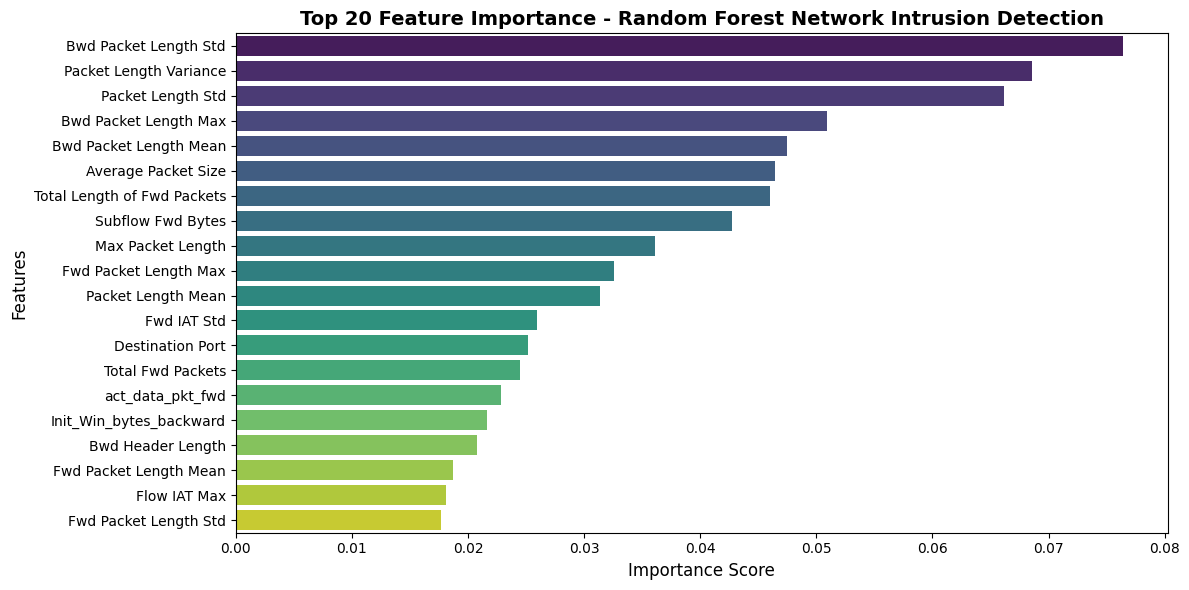

In [6]:
print("\n" + "="*70)
print("STEP 5: Feature Importance Analysis")
print("="*70)

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feat_imp.head(20).to_string(index=False))

# Plot top 20 features
plt.figure(figsize=(12, 6))
sns.barplot(
    data=feat_imp.head(20),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title("Top 20 Feature Importance - Random Forest Network Intrusion Detection", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
print("\n" + "="*70)
print("STEP 6: Model Comparison Summary")
print("="*70)

# Create comparison dataframe
comparison_df = compare_models([rf_results])

print("\nModel Comparison Results:")
print(comparison_df.to_string(index=False))

# Create a summary visualization
print("\n" + "="*70)
print("Training Summary")
print("="*70)
print(f"Total Training Time: {train_time:.2f} seconds")
print(f"Test Set Size: {len(y_test):,} samples")
print(f"Model Type: Random Forest")
print(f"Number of Estimators: 300")
print(f"Number of Features: {X_train.shape[1]}")
print(f"Number of Classes: {len(rf_model.classes_)}")
print("="*70)


STEP 6: Model Comparison Summary

Model Comparison Results:
                           Model  Accuracy  Precision (weighted)  Precision (macro)  Recall (weighted)  Recall (macro)  F1 (weighted)  F1 (macro)  Cohen Kappa    MCC  ROC-AUC (weighted)  ROC-AUC (macro)
Random Forest (n_estimators=300)    0.9982                0.9981             0.8547             0.9982          0.8108         0.9982      0.8268       0.9939 0.9939              0.9998           0.9866

Training Summary
Total Training Time: 260.52 seconds
Test Set Size: 504,153 samples
Model Type: Random Forest
Number of Estimators: 300
Number of Features: 52
Number of Classes: 10
